<a href="https://colab.research.google.com/github/vzKato/Mini-project_Cafe_Aurora/blob/main/Data_Analysis_Caf%C3%A9_Aurora_052026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from google.colab import files

# Subir archivo CSV
# Upload CSV file
uploaded = files.upload()

# Leer el CSV en un DataFrame
# Read the CSV into a DataFrame
df = pd.read_csv("ddbb_cafe_aurora.csv")

# Visualizar las primeras filas
# Display the first few rows
df.head()

Saving ddbb_cafe_aurora.csv to ddbb_cafe_aurora.csv


,Unnamed: 0,id_venta,fecha,ciudad,producto,cantidad,precio_unitario,total
0,0,1,2025-06-13,Querétaro,Espresso,3,35,105
1,1,2,2025-03-04,CDMX,Cappuccino,1,50,50
2,2,3,2025-06-23,Puebla,Chai Latte,1,58,58
3,3,4,2025-06-01,Querétaro,Americano,1,40,40
4,4,5,2025-01-24,CDMX,Cappuccino,5,50,250


In [5]:
# Información general: columnas, tipos y valores nulos
# General information: columns, data types, and null values
df.info()

# Estadísticas básicas de columnas numéricas
# Basic statistics for numeric columns
df.describe()

# ¿Cuántas filas y columnas tiene?
# How many rows and columns does it have?
print("Dimensiones:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       1000 non-null   int64 
 1   id_venta         1000 non-null   int64 
 2   fecha            1000 non-null   object
 3   ciudad           1000 non-null   object
 4   producto         1000 non-null   object
 5   cantidad         1000 non-null   int64 
 6   precio_unitario  1000 non-null   int64 
 7   total            1000 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 62.6+ KB
Dimensiones: (1000, 8)


### Análisis con pandas
### Analysis with pandas

In [7]:
# Productos más vendidos (por cantidad de unidades)
# Best-selling products (by number of units)
ventas_por_producto = df.groupby("producto")["cantidad"].sum().sort_values(ascending=False)
print("Unidades vendidas por producto:")
print(ventas_por_producto)

# Ingresos por ciudad
# Revenue by city
ingresos_por_ciudad = df.groupby("ciudad")["total"].sum().sort_values(ascending=False)
print("\nIngresos por ciudad:")
print(ingresos_por_ciudad)

Unidades vendidas por producto:
producto
Chai Latte    556
Latte         525
Americano     485
Mocha         480
Cappuccino    467
Espresso      433
Name: cantidad, dtype: int64

Ingresos por ciudad:
ciudad
Guadalajara    33550
Querétaro      29986
Monterrey      29350
Puebla         29339
CDMX           25603
Name: total, dtype: int64


In [9]:
# Instalación pandasql
# Installing pandasql
!pip install pandasql -q

from pandasql import sqldf

# Función auxiliar para ejecutar SQL sobre nuestros DataFrames
# Helper function for executing SQL on our DataFrames
consulta = lambda q: sqldf(q,globals())

# Consulta SQL: top 3 productos con más ingresos
# SQL Query: Top 3 Highest-Revenue Products
query = """
SELECT producto,
  SUM(total) AS ingresos_totales,
  SUM(cantidad) AS unidades_vendidas
FROM df
GROUP BY producto
ORDER BY ingresos_totales DESC
LIMIT 3
"""

resultado = consulta(query)
print(resultado)

     producto  ingresos_totales  unidades_vendidas
0  Chai Latte             32248                556
1       Latte             28875                525
2       Mocha             28800                480


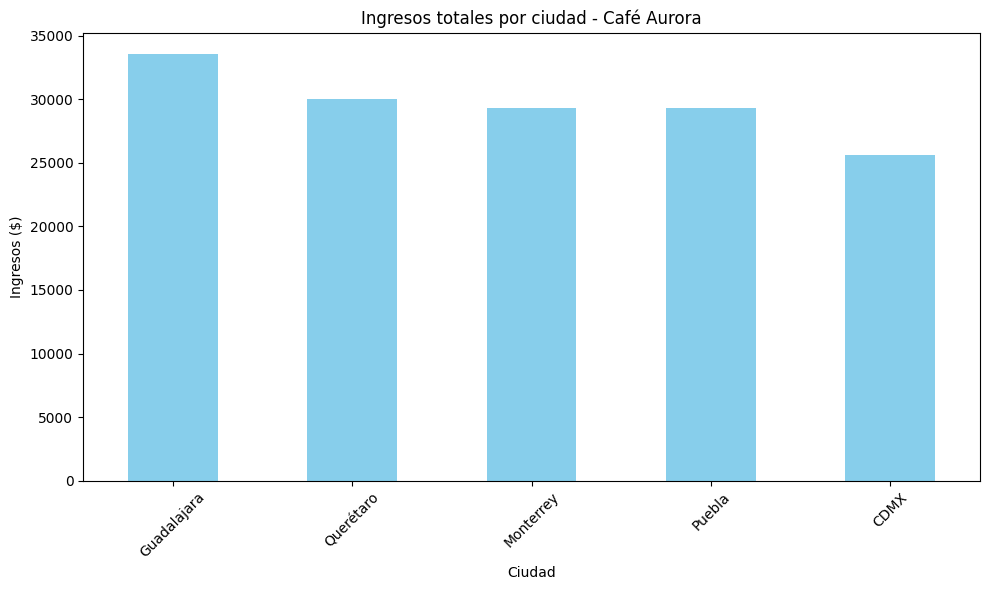

In [10]:
import matplotlib.pyplot as plt

# Calcular ingresos por ciudad
# Calculate income by city
ingresos_ciudad = df.groupby("ciudad")["total"].sum().sort_values(ascending=False)

# Crear gráfico de barras
# Create a bar chart
plt.figure(figsize=(10,6))
ingresos_ciudad.plot(kind="bar", color="skyblue")
plt.title("Ingresos totales por ciudad - Café Aurora")
plt.xlabel("Ciudad")
plt.ylabel("Ingresos ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()